# Notebook 03: Model 1: Soft Sensor for Final Moisture

**Project:** MAP Dryer AI  
**Purpose:** compare regression models that estimate `final_moisture_h₂o` from MAP dryer process measurements before the laboratory result is available.

A soft sensor is a model-based estimate of a difficult or delayed measurement. Here, it uses operational variables such as temperatures, air flow, feed rate, residence time, vacuum, pressure, fan speed, and engineered process features.

## Inputs and evaluation approach

- **Input:** `data/processed/dryerMAP_prototype_processed.csv` (created in Notebook 02)
- **Target:** `final_moisture_h₂o`
- **Models compared:** Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting
- **Evaluation:** chronological 80/20 holdout split, followed by time-series cross-validation on the training period
- **Figure outputs:** `figures/03_Model1_SoftSensor/`

The final holdout set is kept separate during model selection so it can provide an unbiased final check.

## 1. Import libraries and locate the project root

Load the modelling, evaluation, visualisation, and interpretation libraries. The project root is found dynamically so the notebook can run from the repository root or the `notebooks/` directory.

In [2]:
from pathlib import Path
import platform
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    max_error
)

import joblib

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.project_paths import find_project_root

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "03_Model1_SoftSensor"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the processed feature table

Read the dataset prepared in Notebook 02 and parse its temporal columns. This is the feature table used throughout the modelling workflow.

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed_2.csv"

dryerMAP_model = pd.read_csv(
    DATA_PATH,
    parse_dates=["date", "timestamp"]
)

dryerMAP_model["time"] = dryerMAP_model["time"].astype(str)

display(dryerMAP_model.head())
dryerMAP_model.info()

,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.00,47.7,20.96,-1.18,4.69,1270.0,1.023,41.0,0.075,2026-04-23 01:00:00,98.0,91.3,2.362000,651.910,2913.440
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.20,46.6,20.29,-0.63,4.78,1236.0,1.028,43.7,0.087,2026-04-23 03:00:00,96.0,93.1,2.384314,667.766,2834.513
2,2026-04-23,05:00:00,140.1,18.9,23.80,10.25,47.3,20.36,-1.08,4.81,1272.0,1.034,45.7,0.072,2026-04-23 05:00:00,94.4,92.8,2.321951,673.881,2852.436
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238.0,1.033,45.2,0.094,2026-04-23 07:00:00,94.5,91.6,2.273612,666.369,2828.925
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.10,4.84,1267.0,1.025,42.9,0.084,2026-04-23 09:00:00,96.9,93.3,2.264734,676.632,2934.402


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   str           
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   float64       
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 3. Review the modelling dataset

Confirm the number of observations and columns, then inspect descriptive statistics before defining the prediction task.

In [4]:
print(f"Rows: {dryerMAP_model.shape[0]}")
print(f"Columns: {dryerMAP_model.shape[1]}")

from stats.descriptive_statistics import descriptive_summary

descriptive_summary(dryerMAP_model)

Rows: 1080
Columns: 20


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,1080.0,139.398981,1.102617,1.215764,136.300000,138.500000,139.400000,140.200000,142.800000,0.008757,-0.561858
cooler_air_temperature,1080.0,24.262593,3.400296,11.562010,18.500000,21.500000,24.300000,26.700000,33.300000,0.133849,-0.714463
air_flow_rate,1080.0,23.865019,0.846023,0.715754,21.010000,23.250000,23.850000,24.432500,27.000000,0.120657,-0.044226
wet_product_feed_rate,1080.0,10.151824,0.401660,0.161331,9.160000,9.820000,10.150000,10.470000,11.180000,0.015116,-0.914299
product_inlet_temperature,1080.0,47.776574,1.530492,2.342407,43.200000,46.700000,47.700000,48.800000,51.900000,0.026896,-0.292606
residence_time,1080.0,20.566944,0.656325,0.430763,18.450000,20.110000,20.590000,21.002500,22.690000,-0.131308,-0.132351
vacuum,1080.0,-0.997454,0.345143,0.119124,-2.300000,-1.230000,-0.980000,-0.720000,-0.450000,-0.368531,-0.282337
steam_pressure,1080.0,4.789037,0.163048,0.026585,4.270000,4.680000,4.790000,4.900000,5.300000,0.000548,-0.022781
fan_speed,1080.0,1264.725926,32.498391,1056.145388,1148.000000,1241.000000,1263.500000,1288.000000,1392.000000,0.119519,0.091540
product_density,1080.0,1.026453,0.005224,0.000027,1.007000,1.023000,1.026000,1.030000,1.041000,-0.046530,-0.046437


## 4. Define the prediction target and candidate features

The target is final moisture. The feature list combines direct process measurements with the engineered variables created in Notebook 02. Keeping this list explicit makes the soft-sensor inputs auditable.

In [5]:
TARGET = "final_moisture_h₂o"
FEATURES = [
    "dryer_air_temperature",
    "cooler_air_temperature",
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed",
    "product_density",
    "final_product_temp",
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "steam_temp_interaction",
    "heating_index"
]

## 5. Build the feature matrix and target vector

Separate the selected predictors (`X`) from the laboratory moisture target (`y`) and confirm their dimensions.

In [6]:
X = dryerMAP_model[FEATURES]

y = dryerMAP_model[TARGET]

print(X.shape)
print(y.shape)

(1080, 16)
(1080,)


## 6. Create a chronological train/test split

The first 80% of rows are used for development and the final 20% are reserved for testing. This preserves the dataset order and better reflects a forward-looking production prediction setting than a random split.

In [7]:
split_index = int(len(dryerMAP_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 864
Testing samples  : 216


## 7. Scale inputs for linear models

Standardisation is fitted only on the training data and then applied to the test data. Tree-based models below use the original, unscaled features because they do not require scaling.

In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("Training features standardized:", X_train_scaled.shape)
print("Testing features standardized:", X_test_scaled.shape)

Training features standardized: (864, 16)
Testing features standardized: (216, 16)


## 8. Baseline model 1: Linear Regression

Train a simple linear baseline, calculate holdout metrics, and inspect residual errors over time. This establishes a transparent reference point for the more flexible models.

In [9]:
baseline_linear_model = LinearRegression()
baseline_linear_model.fit(X_train_scaled, y_train)

y_pred_linear = baseline_linear_model.predict(X_test_scaled)

print("Linear Regression baseline trained.")

Linear Regression baseline trained.


In [10]:
baseline_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_linear)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_linear))],
        "R²": [r2_score(y_test, y_pred_linear)],
        "Maximum absolute error": [max_error(y_test, y_pred_linear)],
    },
    index=["Linear Regression"],
)

display(baseline_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0048,0.0061,0.8003,0.0194


C:\Users\pc\AppData\Local\Temp\ipykernel_27248\1549171297.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(error_analysis_linear.round(4))


,timestamp,Actual moisture,Predicted moisture,Residual (actual - predicted),Absolute error
864,2026-07-04 01:00:00,0.076,0.0773,-0.0013,0.0013
865,2026-07-04 03:00:00,0.064,0.0576,0.0064,0.0064
866,2026-07-04 05:00:00,0.082,0.0789,0.0031,0.0031
867,2026-07-04 07:00:00,0.087,0.0760,0.0110,0.0110
868,2026-07-04 09:00:00,0.075,0.0774,-0.0024,0.0024
...,...,...,...,...,...
1075,2026-07-21 15:00:00,0.066,0.0743,-0.0083,0.0083
1076,2026-07-21 17:00:00,0.082,0.0770,0.0050,0.0050
1077,2026-07-21 19:00:00,0.065,0.0711,-0.0061,0.0061
1078,2026-07-21 21:00:00,0.075,0.0739,0.0011,0.0011


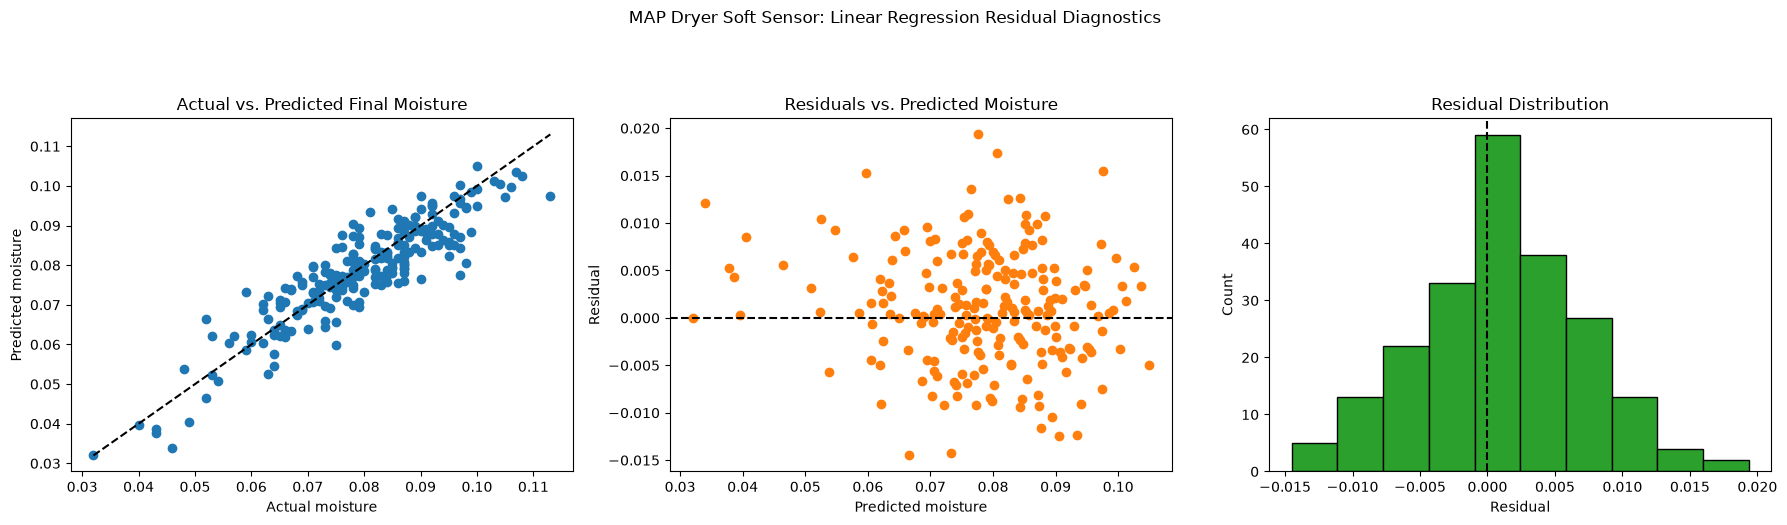

In [11]:
residuals_linear = y_test - y_pred_linear
error_analysis_linear = pd.DataFrame(
    {
        "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
        "Actual moisture": y_test,
        "Predicted moisture": y_pred_linear,
        "Residual (actual - predicted)": residuals_linear,
        "Absolute error": residuals_linear.abs(),
    }
)
display(error_analysis_linear.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MAP Dryer Soft Sensor: Linear Regression Residual Diagnostics", y=1.04)

axis_min = min(y_test.min(), y_pred_linear.min())
axis_max = max(y_test.max(), y_pred_linear.max())
axes[0].scatter(y_test, y_pred_linear, color="tab:blue")
axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "k--")
axes[0].set(xlabel="Actual moisture", ylabel="Predicted moisture", title="Actual vs. Predicted Final Moisture")

axes[1].scatter(y_pred_linear, residuals_linear, color="tab:orange")
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set(xlabel="Predicted moisture", ylabel="Residual", title="Residuals vs. Predicted Moisture")

axes[2].hist(residuals_linear, bins=min(10, len(residuals_linear)), color="tab:green", edgecolor="black")
axes[2].axvline(0, color="k", linestyle="--")
axes[2].set(xlabel="Residual", ylabel="Count", title="Residual Distribution")

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_linear_regression_residual_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 9. Baseline model 2: Ridge Regression

Fit a regularised linear model and evaluate it on the same untouched holdout period. Ridge regression can reduce instability when predictor variables are correlated.

In [12]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge baseline trained.")

Ridge baseline trained.


In [13]:
ridge_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_ridge)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_ridge))],
        "R²": [r2_score(y_test, y_pred_ridge)],
        "Maximum absolute error": [max_error(y_test, y_pred_ridge)],
    },
    index=["Ridge Regression"],
)

display(ridge_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Ridge Regression,0.0048,0.0062,0.7962,0.0178


## 10. Baseline model 3: Random Forest

Train an ensemble of decision trees to capture nonlinear relationships and interactions among the dryer variables, then calculate the same holdout metrics for a fair comparison.

In [14]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(X_train, y_train)
y_pred_random_forest = random_forest_model.predict(X_test)

print("Random Forest baseline trained.")

Random Forest baseline trained.


In [15]:
random_forest_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_random_forest)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_random_forest))],
        "R²": [r2_score(y_test, y_pred_random_forest)],
        "Maximum absolute error": [max_error(y_test, y_pred_random_forest)],
    },
    index=["Random Forest"],
)

display(random_forest_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Random Forest,0.0051,0.0064,0.7783,0.0252


## 11. Baseline model 4: Gradient Boosting

Train a boosting model that builds small decision trees sequentially. Its performance is evaluated with the same holdout set and error measures as the other candidates.

In [16]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

gradient_boosting_model.fit(X_train, y_train)
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print("Gradient Boosting baseline trained.")

Gradient Boosting baseline trained.


In [17]:
gradient_boosting_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_gradient_boosting)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_gradient_boosting))],
        "R²": [r2_score(y_test, y_pred_gradient_boosting)],
        "Maximum absolute error": [max_error(y_test, y_pred_gradient_boosting)],
    },
    index=["Gradient Boosting"],
)

display(gradient_boosting_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Gradient Boosting,0.0052,0.0067,0.7586,0.024


## 12. Compare baseline results

Rank the four baseline models by RMSE. This is an initial comparison only; the next steps use time-series cross-validation and tuning within the training period before selecting the final candidate.

In [18]:
model_comparison = pd.concat(
    [
        baseline_metrics,
        ridge_metrics,
        random_forest_metrics,
        gradient_boosting_metrics,
    ]
).sort_values("RMSE")

display(model_comparison.round(4))
print(f"Best current model by RMSE: {model_comparison.index[0]}")

,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0048,0.0061,0.8003,0.0194
Ridge Regression,0.0048,0.0062,0.7962,0.0178
Random Forest,0.0051,0.0064,0.7783,0.0252
Gradient Boosting,0.0052,0.0067,0.7586,0.0240


Best current model by RMSE: Linear Regression


## 13. Validate with time-series cross-validation

Use expanding time-series splits within the training data to estimate how each model performs across multiple forward-looking validation periods. MAE, RMSE, and R² are reported for each candidate.

In [19]:
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline

tscv = TimeSeriesSplit(n_splits=3)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R²": "r2",
}

cv_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
    ),
}

cv_rows = []
for model_name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=tscv, scoring=scoring)
    cv_rows.append(
        {
            "Model": model_name,
            "CV MAE": -scores["test_MAE"].mean(),
            "CV RMSE": -scores["test_RMSE"].mean(),
            "CV R²": scores["test_R²"].mean(),
        }
    )

cross_validation_results = (
    pd.DataFrame(cv_rows).set_index("Model").sort_values("CV RMSE")
)
display(cross_validation_results.round(4))

,CV MAE,CV RMSE,CV R²
Model,,,
Linear Regression,0.0046,0.0060,0.8034
Ridge Regression,0.0051,0.0067,0.7521
Random Forest,0.0053,0.0069,0.7340
Gradient Boosting,0.0053,0.0069,0.7305


## 14. Tune the nonlinear and regularised candidates

Use grid search with the same time-series cross-validation strategy to test a small, interpretable set of hyperparameter choices for Ridge, Random Forest, and Gradient Boosting.

In [20]:
tuning_searches = {
    "Ridge Regression": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        scoring="neg_root_mean_squared_error",
        cv=tscv,
    ),
    "Random Forest": GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid={
            "n_estimators": [100, 200],
            "max_depth": [None, 3],
            "min_samples_leaf": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
    "Gradient Boosting": GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_grid={
            "n_estimators": [50, 100],
            "learning_rate": [0.03, 0.05],
            "max_depth": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
}

tuning_rows = []
for model_name, search in tuning_searches.items():
    search.fit(X_train, y_train)
    tuning_rows.append(
        {
            "Model": model_name,
            "Best CV RMSE": -search.best_score_,
            "Best parameters": search.best_params_,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows).set_index("Model").sort_values("Best CV RMSE")
)
display(tuning_results)

,Best CV RMSE,Best parameters
Model,,
Ridge Regression,0.006170,{'model__alpha': 0.01}
Random Forest,0.006788,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
Gradient Boosting,0.006927,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."


## 15. Select and refit the final candidate

Choose the candidate with the lowest cross-validation RMSE, then fit that selected model on the complete training period. The chronological test set remains untouched until the final evaluation.

In [21]:
selection_results = pd.concat(
    [
        pd.DataFrame(
            {"Selection CV RMSE": [cross_validation_results.loc["Linear Regression", "CV RMSE"]]},
            index=["Linear Regression"],
        ),
        tuning_results[["Best CV RMSE"]].rename(
            columns={"Best CV RMSE": "Selection CV RMSE"}
        ),
    ]
).sort_values("Selection CV RMSE")

final_model_name = selection_results.index[0]
final_model_candidates = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": tuning_searches["Ridge Regression"].best_estimator_,
    "Random Forest": tuning_searches["Random Forest"].best_estimator_,
    "Gradient Boosting": tuning_searches["Gradient Boosting"].best_estimator_,
}

final_model = final_model_candidates[final_model_name]
final_model.fit(X_train, y_train)

display(selection_results.round(4))
print(
    f"Selected final candidate: {final_model_name}. "
    "The chronological test set remains untouched for Task 20."
)

,Selection CV RMSE
Linear Regression,0.0060
Ridge Regression,0.0062
Random Forest,0.0068
Gradient Boosting,0.0069


Selected final candidate: Linear Regression. The chronological test set remains untouched for Task 20.


## 16. Inspect global feature importance

Rank the influence of input features in the selected model. For tree models this is impurity-based importance; for linear models it is the absolute standardised coefficient. These scores describe model behaviour, not causal effects.

,Feature,Importance
0,heating_index,0.327972
1,residence_time,0.317067
2,steam_temp_interaction,0.112983
3,steam_pressure,0.106592
4,dryer_air_temperature,0.033732
5,air_product_delta,0.015066
6,final_product_temp,0.009756
7,air_per_feed,0.009692
8,temperature_drop,0.008796
9,air_flow_rate,0.006355


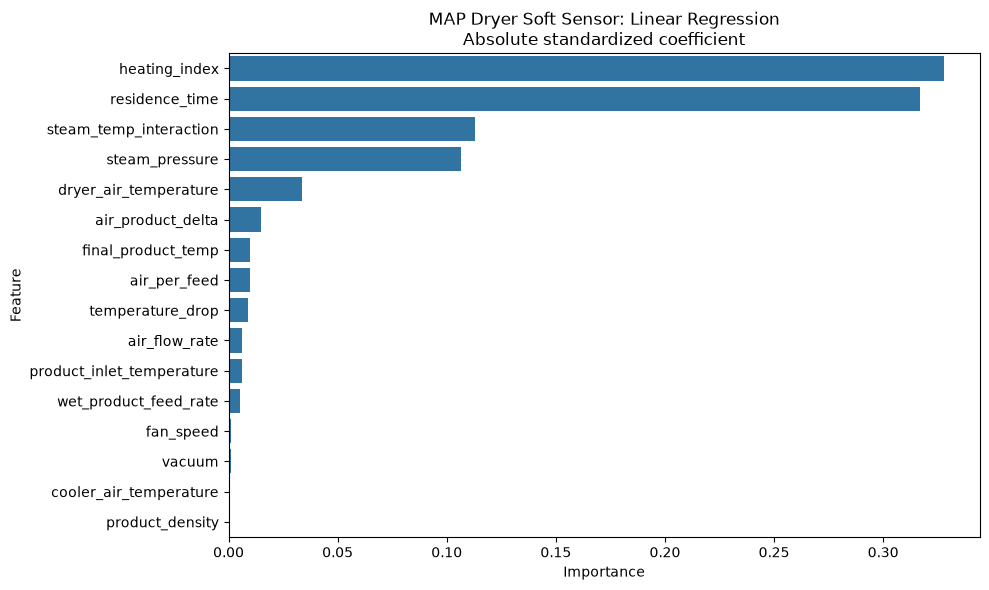

In [22]:
final_estimator = (
    final_model.named_steps["model"]
    if isinstance(final_model, Pipeline)
    else final_model
)

if hasattr(final_estimator, "feature_importances_"):
    importance_values = final_estimator.feature_importances_
    importance_method = "Impurity-based feature importance"
elif hasattr(final_estimator, "coef_"):
    importance_values = np.abs(np.ravel(final_estimator.coef_))
    importance_method = "Absolute standardized coefficient"
else:
    raise TypeError(f"Feature importance is not available for {final_model_name}.")

feature_importance = (
    pd.DataFrame({"Feature": X_train.columns, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", color="tab:blue")
plt.title(f"MAP Dryer Soft Sensor: {final_model_name}\n{importance_method}")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_selected_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 17. Explain predictions with SHAP

SHAP summaries show how strongly each feature contributes to the selected model's predictions across the training data. Use them to understand model patterns, while keeping normal process-engineering validation in the loop.

c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 864 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=864 when initializing the masker.


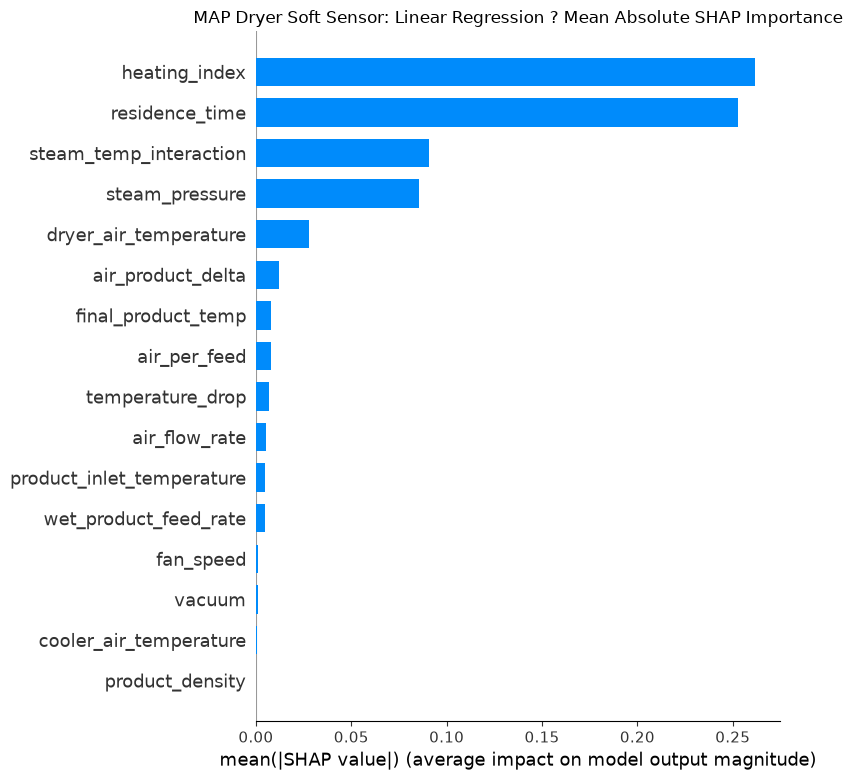

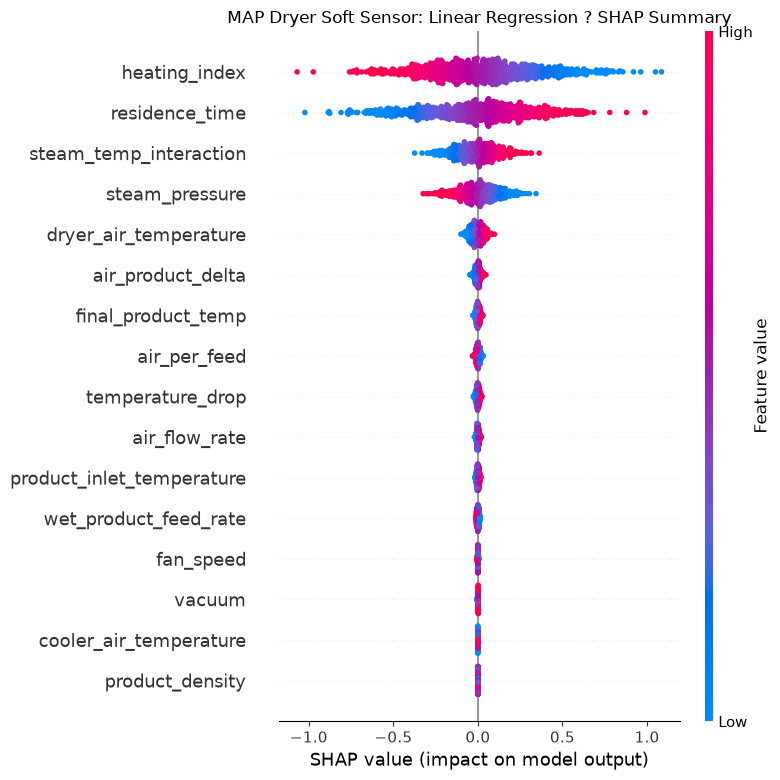

In [23]:
import shap

if hasattr(final_estimator, "feature_importances_"):
    X_explain = X_train
    shap_explainer = shap.TreeExplainer(final_estimator)
    shap_values = shap_explainer.shap_values(X_explain)
elif isinstance(final_model, Pipeline) and "scaler" in final_model.named_steps:
    X_explain = pd.DataFrame(
        final_model.named_steps["scaler"].transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)
else:
    X_explain = X_train
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} ? Mean Absolute SHAP Importance")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_selected_model_shap_global_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

shap.summary_plot(shap_values, X_explain, show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} ? SHAP Summary")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "04_selected_model_shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 18. Final evaluation on the untouched test period

Evaluate the selected model once on the held-out chronological test set using MAE, RMSE, R², and maximum absolute error. The time-series plot compares predicted and actual final moisture over that period.

,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0048,0.0061,0.8003,0.0194


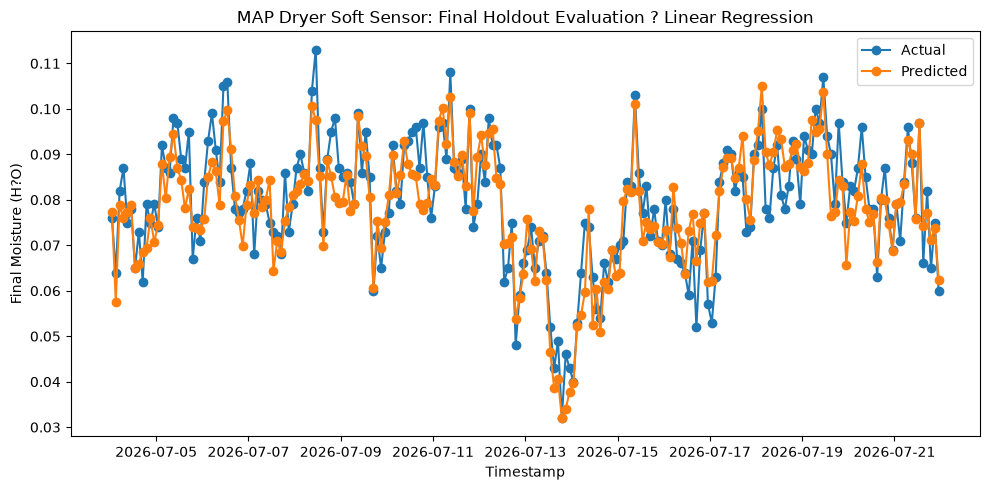

In [24]:
y_pred_final = final_model.predict(X_test)

final_test_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_final)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_final))],
        "R²": [r2_score(y_test, y_pred_final)],
        "Maximum absolute error": [max_error(y_test, y_pred_final)],
    },
    index=[final_model_name],
)

final_test_predictions = pd.DataFrame(
    {
        "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
        "Actual moisture": y_test,
        "Predicted moisture": y_pred_final,
        "Residual (actual - predicted)": y_test - y_pred_final,
    }
)

display(final_test_metrics.round(4))

plt.figure(figsize=(10, 5))
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Actual moisture"], marker="o", label="Actual")
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Predicted moisture"], marker="o", label="Predicted")
plt.title(f"MAP Dryer Soft Sensor: Final Holdout Evaluation ? {final_model_name}")
plt.xlabel("Timestamp")
plt.ylabel("Final Moisture (H?O)")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "05_final_holdout_predictions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 19. Check for overfitting across training, validation, and testing

Compare the selected model on the data used to fit it, out-of-fold predictions from the chronological validation splits, and the untouched test period. Large increases in RMSE together with decreases in R2 from training to validation or testing are evidence that the model may be overfitting. The warning below uses a transparent heuristic: an RMSE increase greater than 20% and an R2 decrease greater than 0.10.

,Samples,MAE,RMSE,R2,Maximum absolute error,RMSE increase vs training (%),R2 decrease vs training,Overfitting signal
Training,864,0.0046,0.0058,0.8254,0.0186,0.0000,0.0000,Reference
Validation (time-series CV),648,0.0046,0.0060,0.8053,0.0203,2.6101,0.0201,No
Testing,216,0.0048,0.0061,0.8003,0.0194,5.1233,0.0251,No


No material overfitting signal under the stated 20% RMSE / 0.10 R2 heuristic.


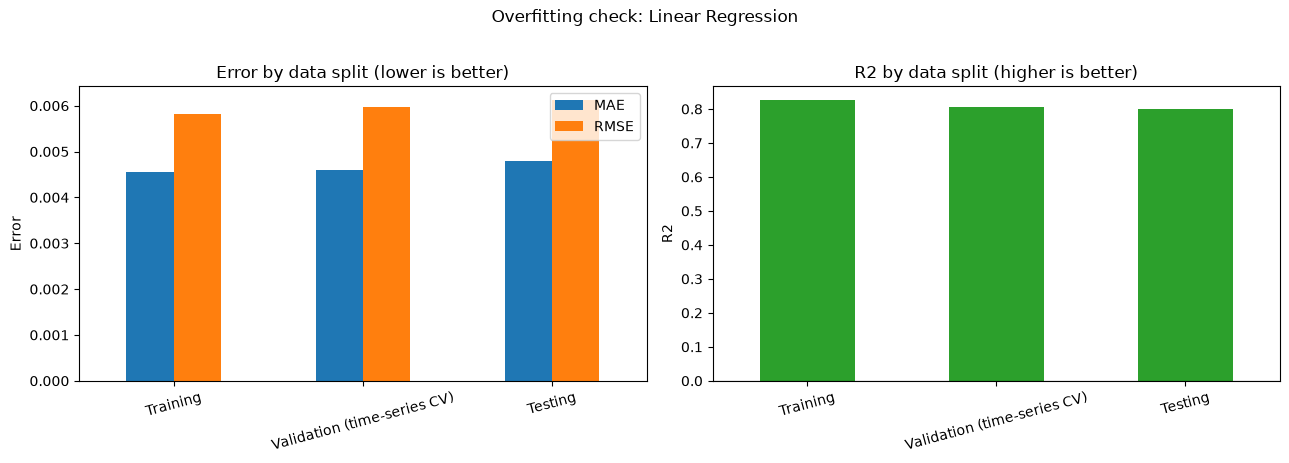

In [25]:
from sklearn.base import clone


def calculate_regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Maximum absolute error": max_error(actual, predicted),
    }


# Training predictions from the selected model fitted on the complete training period.
y_pred_train_final = final_model.predict(X_train)

# Generate strictly forward-looking validation predictions for every time-series fold.
validation_actual = []
validation_predicted = []
for fold_train_index, fold_validation_index in tscv.split(X_train):
    fold_model = clone(final_model)
    fold_model.fit(
        X_train.iloc[fold_train_index],
        y_train.iloc[fold_train_index],
    )
    validation_actual.extend(y_train.iloc[fold_validation_index].to_numpy())
    validation_predicted.extend(
        fold_model.predict(X_train.iloc[fold_validation_index])
    )

train_validation_test_metrics = pd.DataFrame(
    [
        calculate_regression_metrics(y_train, y_pred_train_final),
        calculate_regression_metrics(validation_actual, validation_predicted),
        calculate_regression_metrics(y_test, y_pred_final),
    ],
    index=["Training", "Validation (time-series CV)", "Testing"],
)
train_validation_test_metrics.insert(
    0, "Samples", [len(y_train), len(validation_actual), len(y_test)]
)

training_rmse = train_validation_test_metrics.loc["Training", "RMSE"]
training_r2 = train_validation_test_metrics.loc["Training", "R2"]
if np.isclose(training_rmse, 0):
    rmse_increase = pd.Series(
        [0.0, np.inf, np.inf], index=train_validation_test_metrics.index
    )
else:
    rmse_increase = (
        train_validation_test_metrics["RMSE"] / training_rmse - 1
    ) * 100

train_validation_test_metrics["RMSE increase vs training (%)"] = rmse_increase
train_validation_test_metrics["R2 decrease vs training"] = (
    training_r2 - train_validation_test_metrics["R2"]
)
train_validation_test_metrics["Overfitting signal"] = np.where(
    (train_validation_test_metrics["RMSE increase vs training (%)"] > 20)
    & (train_validation_test_metrics["R2 decrease vs training"] > 0.10),
    "Yes",
    "No",
)
train_validation_test_metrics.loc["Training", "Overfitting signal"] = "Reference"

display(train_validation_test_metrics.round(4))

validation_warning = (
    train_validation_test_metrics.loc[
        "Validation (time-series CV)", "Overfitting signal"
    ]
    == "Yes"
)
test_warning = (
    train_validation_test_metrics.loc["Testing", "Overfitting signal"]
    == "Yes"
)
if validation_warning and test_warning:
    print("Overfitting warning: both validation and test performance degrade materially.")
elif validation_warning or test_warning:
    print("Possible overfitting: one unseen-data comparison shows a material gap.")
else:
    print("No material overfitting signal under the stated 20% RMSE / 0.10 R2 heuristic.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
train_validation_test_metrics[["MAE", "RMSE"]].plot(
    kind="bar", ax=axes[0], rot=15, color=["tab:blue", "tab:orange"]
)
axes[0].set_title("Error by data split (lower is better)")
axes[0].set_ylabel("Error")
axes[0].set_xlabel("")
axes[0].legend(loc="best")

train_validation_test_metrics["R2"].plot(
    kind="bar", ax=axes[1], rot=15, color="tab:green"
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R2 by data split (higher is better)")
axes[1].set_ylabel("R2")
axes[1].set_xlabel("")
fig.suptitle(f"Overfitting check: {final_model_name}", y=1.02)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "06_train_validation_test_overfitting_check.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Next step

Use these results as the soft-sensor baseline. The later notebooks are reserved for off-spec classification, anomaly detection, and model comparison as the MAP Dryer AI workflow expands.